# Part I — When Do U.S. Flights Arrive Late?
## Exploratory visualization of January 2023 domestic flights

**Author:** Devin Thomas  
**Course:** Data Visualization with Matplotlib and Seaborn

## Introduction

This report explores U.S. Reporting Carrier On-Time Performance data published by the Bureau of Transportation Statistics (BTS). The analysis uses all January 2023 records from the official monthly archive, reduced to 16 variables needed for the investigation.

The overarching question is: **When and where is a traveler most likely to encounter an arrival delay?** I examine arrival delay minutes and the 15-minute delay indicator against carrier, scheduled departure hour, day of week, route distance, and departure delay.

## Preliminary Wrangling

The source archive contains more than 100 operational fields. The submitted extract retains the flight date, schedule, carrier, airports, delay measures, cancellation flag, distance, and cause-specific delay fields. Canceled flights have no arrival delay and are excluded only from arrival-delay plots; they remain in the dataset for an honest accounting of the source rows.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook", palette="colorblind")
pd.set_option("display.max_columns", 25)

DATA_PATH = Path("data/flights_2023_01.csv")
flights_raw = pd.read_csv(DATA_PATH, parse_dates=["FlightDate"], low_memory=False)

CARRIER_NAMES = {
    "9E": "Endeavor", "AA": "American", "AS": "Alaska", "B6": "JetBlue",
    "DL": "Delta", "F9": "Frontier", "G4": "Allegiant", "HA": "Hawaiian",
    "MQ": "Envoy", "NK": "Spirit", "OO": "SkyWest", "UA": "United",
    "WN": "Southwest", "YV": "Mesa",
}
DAY_NAMES = {1: "Monday", 2: "Tuesday", 3: "Wednesday", 4: "Thursday", 5: "Friday", 6: "Saturday", 7: "Sunday"}
DAY_ORDER = list(DAY_NAMES.values())

flights = flights_raw.copy()
flights["carrier_name"] = flights["Reporting_Airline"].map(CARRIER_NAMES).fillna(flights["Reporting_Airline"])
flights["dep_hour"] = (pd.to_numeric(flights["CRSDepTime"], errors="coerce") // 100).replace(24, 0)
flights["day_name"] = pd.Categorical(flights["DayOfWeek"].map(DAY_NAMES), categories=DAY_ORDER, ordered=True)
flights["dep_period"] = pd.cut(
    flights["dep_hour"], bins=[-1, 4, 11, 16, 23], labels=["Overnight", "Morning", "Afternoon", "Evening"]
)
operated = flights.query("Cancelled == 0").dropna(subset=["ArrDelayMinutes", "ArrDel15"]).copy()
operated["arr_delay_capped"] = operated["ArrDelayMinutes"].clip(upper=180)

print(f"Rows: {len(flights):,}; operated flights with arrival data: {len(operated):,}")
display(flights.head())

Rows: 538,837; operated flights with arrival data: 527,197


,DayOfWeek,FlightDate,Reporting_Airline,Origin,Dest,CRSDepTime,DepDelayMinutes,ArrDelayMinutes,ArrDel15,Cancelled,Distance,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,carrier_name,dep_hour,day_name,dep_period
0,1,2023-01-02,9E,BDL,LGA,800,0.0,0.0,0.0,0.0,101.0,NaN,NaN,NaN,NaN,NaN,Endeavor,8,Monday,Morning
1,2,2023-01-03,9E,BDL,LGA,800,0.0,0.0,0.0,0.0,101.0,NaN,NaN,NaN,NaN,NaN,Endeavor,8,Tuesday,Morning
2,3,2023-01-04,9E,BDL,LGA,800,0.0,0.0,0.0,0.0,101.0,NaN,NaN,NaN,NaN,NaN,Endeavor,8,Wednesday,Morning
3,4,2023-01-05,9E,BDL,LGA,800,0.0,0.0,0.0,0.0,101.0,NaN,NaN,NaN,NaN,NaN,Endeavor,8,Thursday,Morning
4,5,2023-01-06,9E,BDL,LGA,800,0.0,0.0,0.0,0.0,101.0,NaN,NaN,NaN,NaN,NaN,Endeavor,8,Friday,Morning


In [2]:
display(flights.dtypes.to_frame("dtype"))
display(flights.isna().sum().sort_values(ascending=False).to_frame("missing"))
print(f"Duplicate rows: {flights.duplicated().sum():,}")
print(f"Canceled flights: {int(flights['Cancelled'].sum()):,}")
print(f"Date range: {flights['FlightDate'].min().date()} to {flights['FlightDate'].max().date()}")
assert flights["FlightDate"].notna().all()
assert operated["ArrDelayMinutes"].ge(0).all()

,dtype
DayOfWeek,int64
FlightDate,datetime64[us]
Reporting_Airline,str
Origin,str
Dest,str
CRSDepTime,int64
DepDelayMinutes,float64
ArrDelayMinutes,float64
ArrDel15,float64
Cancelled,float64


,missing
WeatherDelay,422124
NASDelay,422124
SecurityDelay,422124
CarrierDelay,422124
LateAircraftDelay,422124
ArrDelayMinutes,11640
ArrDel15,11640
DepDelayMinutes,9982
Origin,0
Reporting_Airline,0


Duplicate rows: 44
Canceled flights: 10,295
Date range: 2023-01-01 to 2023-01-31


### Structure and features of interest

Each row is a scheduled domestic flight. Most retained fields are numeric; carrier and airport codes are categorical. Arrival delay is reported as nonnegative minutes in `ArrDelayMinutes`, while `ArrDel15` marks flights arriving at least 15 minutes late. The main feature of interest is arrival delay, supported by carrier, departure hour, day of week, route distance, and departure delay.

## Univariate Exploration

**Questions and assumptions.** How are delay minutes distributed among operated flights, and how much traffic does each carrier contribute? Delay minutes are expected to be right-skewed; carrier counts provide context so a high-rate carrier is not confused with a high-volume carrier.

### 1. What does the distribution of arrival delay look like?

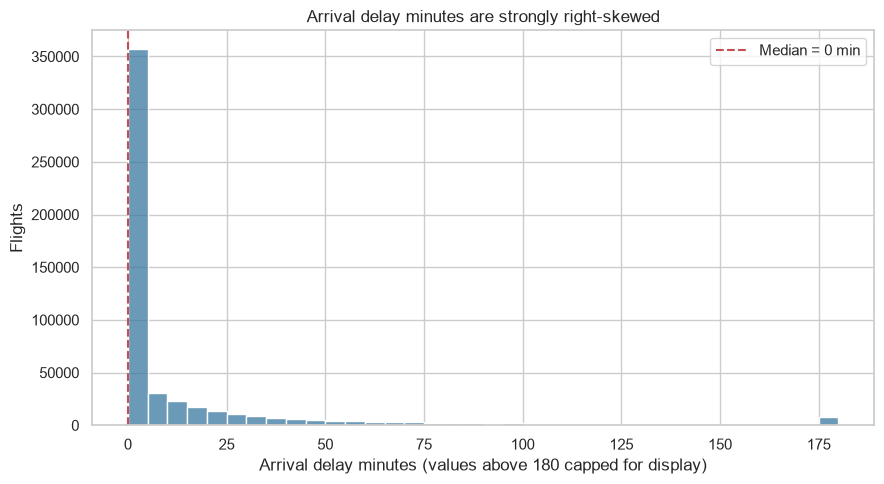

count    527197.000000
mean         16.438893
std          53.919981
min           0.000000
50%           0.000000
75%          11.000000
90%          45.000000
95%          85.000000
99%         210.000000
max        3063.000000
Name: ArrDelayMinutes, dtype: float64

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(operated["arr_delay_capped"], bins=np.arange(0, 185, 5), color="#3a78a1", ax=ax)
ax.axvline(operated["ArrDelayMinutes"].median(), color="#c44e52", linestyle="--", label=f"Median = {operated['ArrDelayMinutes'].median():.0f} min")
ax.set(title="Arrival delay minutes are strongly right-skewed", xlabel="Arrival delay minutes (values above 180 capped for display)", ylabel="Flights")
ax.legend()
plt.tight_layout()
plt.show()
operated["ArrDelayMinutes"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])

Most operated flights have no positive arrival delay, while a much smaller group forms a long tail. Capping only the displayed values at 180 minutes keeps the body visible without altering calculations.

### 2. How is flight volume distributed across carriers?

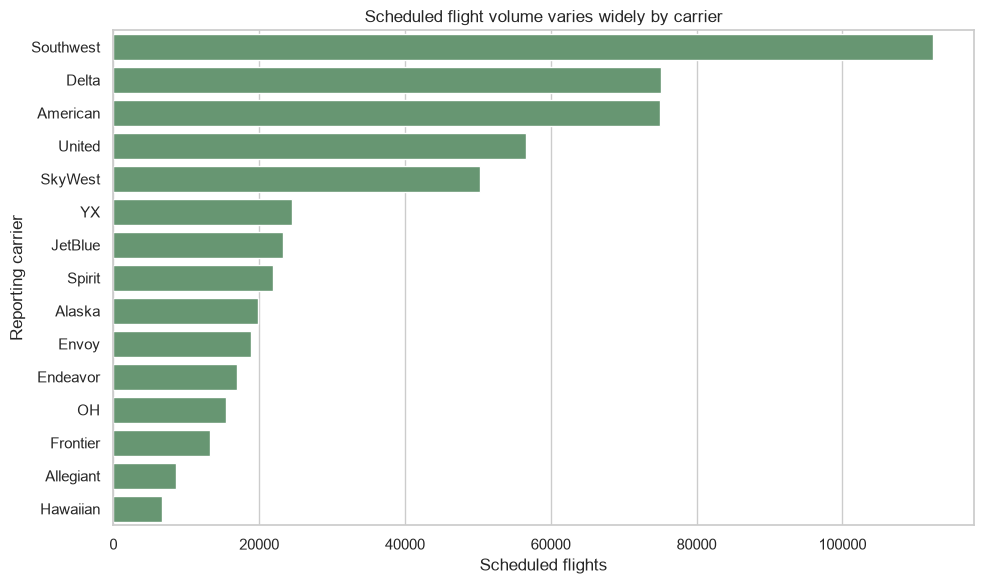

In [4]:
carrier_order = flights["carrier_name"].value_counts().index
fig, ax = plt.subplots(figsize=(10, 6))
sns.countplot(data=flights, y="carrier_name", order=carrier_order, color="#5f9e6e", ax=ax)
ax.set(title="Scheduled flight volume varies widely by carrier", xlabel="Scheduled flights", ylabel="Reporting carrier")
plt.tight_layout()
plt.show()

Southwest, Delta, American, SkyWest, and United account for much of the month's traffic. Later carrier comparisons therefore use rates or distributions rather than raw delayed-flight counts.

## Bivariate Exploration

**Questions and assumptions.** Do longer flights arrive later, do carrier distributions differ, and does delay risk vary jointly by weekday and scheduled hour? A random point sample is used only to keep the scatter plot readable; grouped summaries use all eligible rows.

### 3. Is route distance associated with arrival delay?

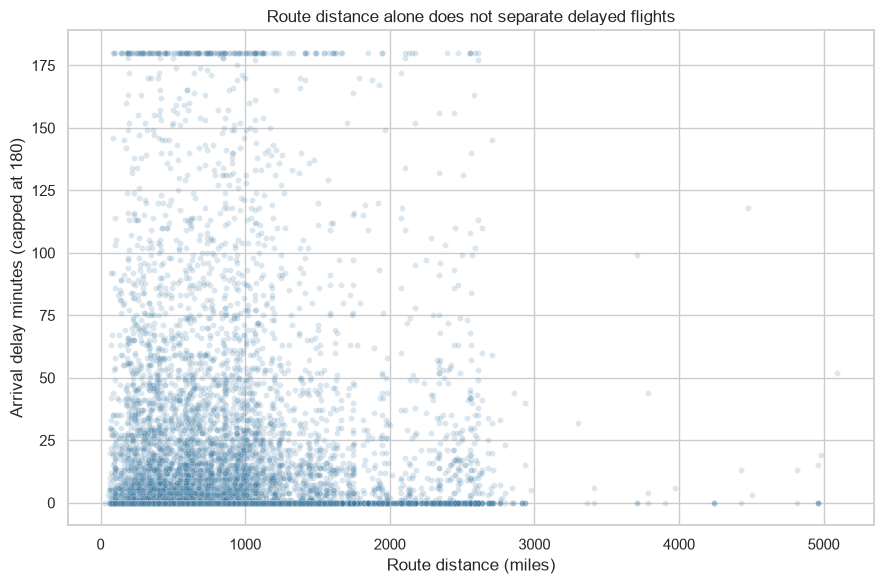

Spearman correlation: 0.040


In [5]:
scatter_sample = operated.sample(n=min(12_000, len(operated)), random_state=42)
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=scatter_sample, x="Distance", y="arr_delay_capped", alpha=0.18, s=18, color="#3a78a1", ax=ax)
ax.set(title="Route distance alone does not separate delayed flights", xlabel="Route distance (miles)", ylabel="Arrival delay minutes (capped at 180)")
plt.tight_layout()
plt.show()
print(f"Spearman correlation: {operated[['Distance', 'ArrDelayMinutes']].corr(method='spearman').iloc[0, 1]:.3f}")

Distance has little monotonic association with positive arrival-delay minutes in this month. Both short and long routes include on-time and severely delayed flights, suggesting schedule and operational factors matter more.

### 4. How do arrival-delay distributions differ by carrier?

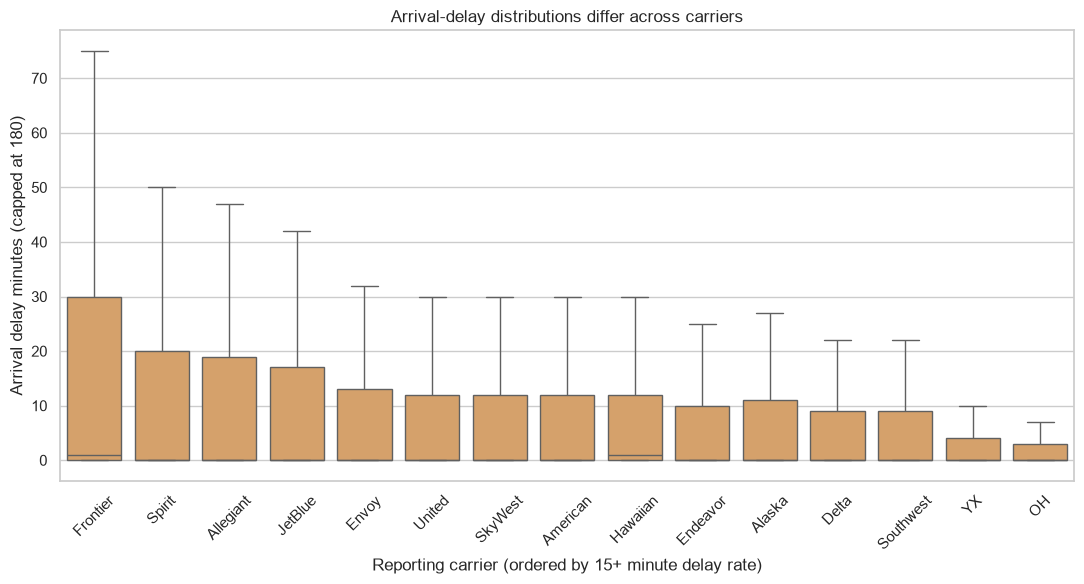

,delay_rate
carrier_name,
Frontier,0.351185
Spirit,0.290847
Allegiant,0.284501
JetBlue,0.264775
Envoy,0.233233
United,0.231097
SkyWest,0.230890
American,0.227231
Hawaiian,0.222642


In [6]:
carrier_rate = operated.groupby("carrier_name")["ArrDel15"].mean().sort_values(ascending=False)
box_order = carrier_rate.index
fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(data=operated, x="carrier_name", y="arr_delay_capped", order=box_order, showfliers=False, color="#e6a15a", ax=ax)
ax.set(title="Arrival-delay distributions differ across carriers", xlabel="Reporting carrier (ordered by 15+ minute delay rate)", ylabel="Arrival delay minutes (capped at 180)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()
carrier_rate.to_frame("delay_rate")

The centers are compressed near zero, but the upper distributions differ. Frontier, JetBlue, and Spirit are among the carriers with higher 15-minute delay rates in this one-month snapshot; this comparison does not adjust for route networks or weather exposure.

### 5. How does delay risk vary by weekday and departure hour?

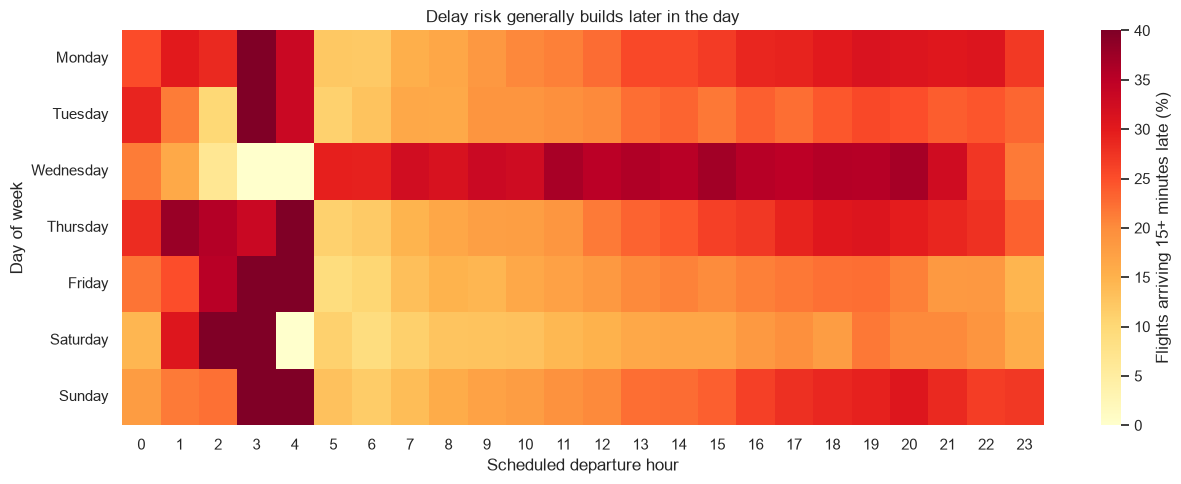

In [7]:
hour_day = operated.pivot_table(index="day_name", columns="dep_hour", values="ArrDel15", aggfunc="mean", observed=False)
fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(hour_day * 100, cmap="YlOrRd", annot=False, vmin=0, vmax=40, cbar_kws={"label": "Flights arriving 15+ minutes late (%)"}, ax=ax)
ax.set(title="Delay risk generally builds later in the day", xlabel="Scheduled departure hour", ylabel="Day of week")
plt.tight_layout()
plt.show()

Departures scheduled from roughly 5–10 a.m. have the lowest delay share on most days. Risk rises into the afternoon and evening, consistent with delays accumulating through an operating day. The overnight 3–4 a.m. cells are volatile because very few flights are scheduled then.

## Multivariate Exploration

**Questions and assumptions.** Does the later-day pattern persist across carriers, and how do departure delays interact with distance and time period? Carrier facets use the four largest carriers for legibility.

### 6. Does the hourly pattern persist for major carriers?

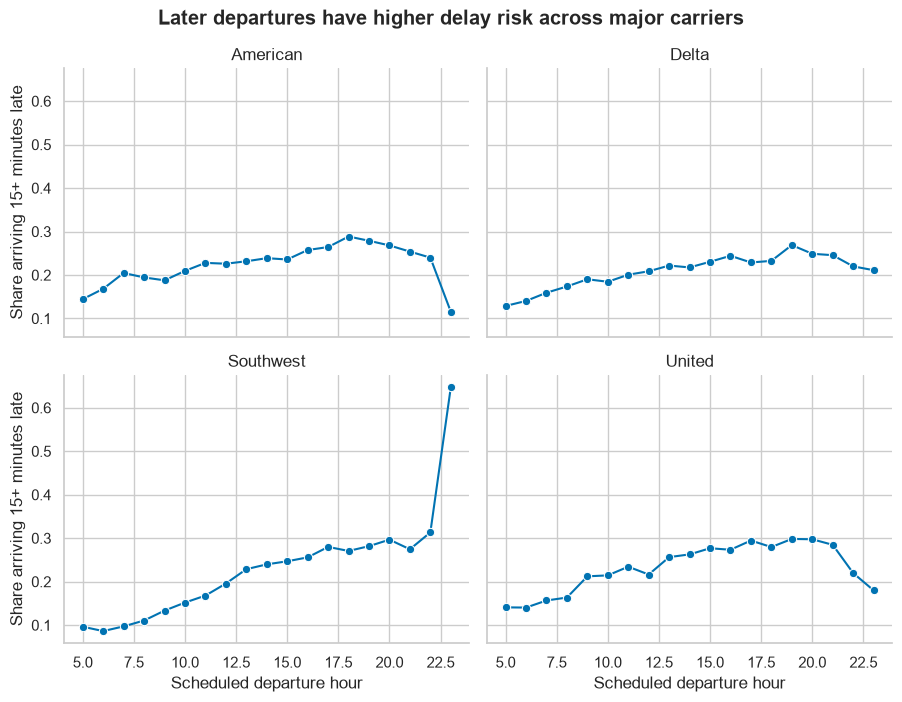

In [8]:
major_carriers = flights["carrier_name"].value_counts().head(4).index
facet_data = operated[operated["carrier_name"].isin(major_carriers) & operated["dep_hour"].ge(5)]
grid = sns.relplot(
    data=facet_data,
    x="dep_hour",
    y="ArrDel15",
    col="carrier_name",
    col_wrap=2,
    kind="line",
    estimator="mean",
    errorbar=None,
    marker="o",
    height=3.4,
    aspect=1.35,
)
grid.set_axis_labels("Scheduled departure hour", "Share arriving 15+ minutes late")
grid.set_titles("{col_name}")
grid.fig.suptitle("Later departures have higher delay risk across major carriers", y=1.03, weight="bold")
plt.show()

The absolute levels differ, but all four major carriers show lower risk in the morning and higher risk later. The repeated shape strengthens the interpretation that time of day matters beyond one carrier's network.

### 7. How do departure delay, distance, and time period combine?

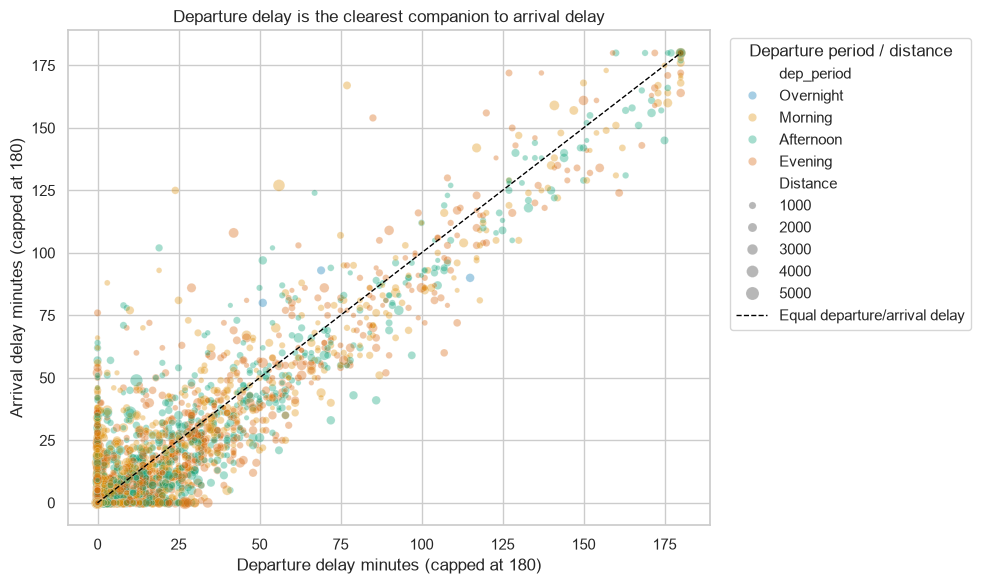

In [9]:
multi_sample = operated.sample(n=min(6_000, len(operated)), random_state=7).copy()
multi_sample["dep_delay_capped"] = multi_sample["DepDelayMinutes"].clip(upper=180)
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=multi_sample,
    x="dep_delay_capped",
    y="arr_delay_capped",
    hue="dep_period",
    size="Distance",
    sizes=(12, 90),
    alpha=0.35,
    ax=ax,
)
ax.plot([0, 180], [0, 180], linestyle="--", color="black", linewidth=1, label="Equal departure/arrival delay")
ax.set(title="Departure delay is the clearest companion to arrival delay", xlabel="Departure delay minutes (capped at 180)", ylabel="Arrival delay minutes (capped at 180)")
ax.legend(title="Departure period / distance", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

Departure and arrival delay move together much more clearly than distance and arrival delay. Many points fall below the equality line, indicating some delay recovery in flight. Evening points are common in the high-delay region, which agrees with the hourly heatmap and facets.

## Conclusions

- Arrival delay is strongly right-skewed: most operated flights have little or no positive delay, while a small tail is severe.
- Delay risk generally increases after the 5–10 a.m. window, and the pattern appears across major carriers.
- Carrier delay rates differ, but these descriptive comparisons do not adjust for route, airport, or weather mix.
- Route distance has little standalone association with arrival delay; departure delay is much more closely related.

The investigation moved from distributions and traffic context to carrier, schedule, and operational relationships. Its largest limitation is time coverage: January 2023 cannot represent every season or long-run carrier performance. Canceled flights are also absent from arrival-delay distributions because no arrival occurred.